# BMI Prediction using Machine Learning

## Submitted by: **Nikhil B Nair**


## **Objective**: To estimate a person's Body Mass Index (BMI) using Gender, Height and Weight with Linear Regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("bmi.csv")
df.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


Dataset Info

In [4]:
print(df.shape)

print()

print(df.info())

print()

print(df.describe())

(500, 4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB
None

           Height      Weight       Index
count  500.000000  500.000000  500.000000
mean   169.944000  106.000000    3.748000
std     16.375261   32.382607    1.355053
min    140.000000   50.000000    0.000000
25%    156.000000   80.000000    3.000000
50%    170.500000  106.000000    4.000000
75%    184.000000  136.000000    5.000000
max    199.000000  160.000000    5.000000


Check for missing values

In [5]:
df.isnull().sum()

,0
Gender,0
Height,0
Weight,0
Index,0


Encode gender

In [6]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df.head()

,Gender,Height,Weight,Index
0,1,174,96,4
1,1,189,87,2
2,0,185,110,4
3,0,195,104,3
4,1,149,61,3


Calculate BMI

In [7]:
df["Height_m"] = df["Height"] / 100

df["BMI"] = df["Weight"] / (df["Height_m"] ** 2)

df.head()

,Gender,Height,Weight,Index,Height_m,BMI
0,1,174,96,4,1.74,31.708284
1,1,189,87,2,1.89,24.355421
2,0,185,110,4,1.85,32.140248
3,0,195,104,3,1.95,27.350427
4,1,149,61,3,1.49,27.476240


Visualize

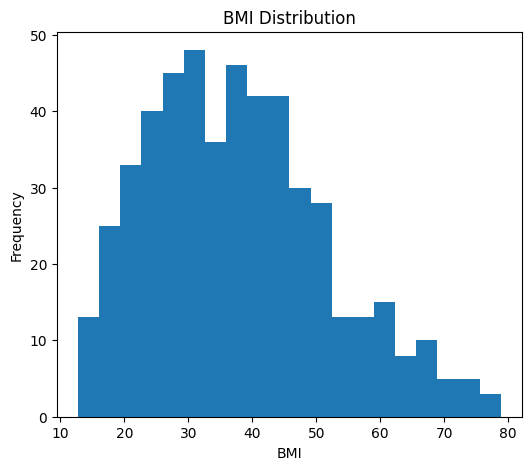

In [8]:
plt.figure(figsize=(6,5))

plt.hist(df["BMI"], bins=20)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

Shows how BMI values are distributed in the dataset

In [9]:
X = df[["Gender", "Height", "Weight"]]
y = df["BMI"]
print(X.head())
print()
print(y.head())

   Gender  Height  Weight
0       1     174      96
1       1     189      87
2       0     185     110
3       0     195     104
4       1     149      61

0    31.708284
1    24.355421
2    32.140248
3    27.350427
4    27.476240
Name: BMI, dtype: float64


##Train test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (400, 3)
Testing Data : (100, 3)


In [11]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained")

Model trained


In [12]:
predictions = model.predict(X_test)
predictions[:10]

array([40.71632868, 22.35229742, 32.08647672, 32.52748974, 39.76761355,
       62.57731759, 46.87454692, 58.13313021, 31.82364289, 59.31349015])

##Evaluating Model

In [13]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error :", round(mae,3))
print("Mean Squared Error :", round(mse,3))
print("Root Mean Squared Error :", round(rmse,3))
print("R2 Score :", round(r2,3))

Mean Absolute Error : 1.887
Mean Squared Error : 6.587
Root Mean Squared Error : 2.567
R2 Score : 0.971


Demonstrates that the model predicts BMI with good accuracy.

###Actual Vs Predicted BMI

In [14]:
comparison = pd.DataFrame({
    "Actual BMI": y_test.values,
    "Predicted BMI": predictions
})

comparison.head(20)

,Actual BMI,Predicted BMI
0,39.736121,40.716329
1,23.148148,22.352297
2,31.377989,32.086477
3,32.146313,32.527490
4,37.977431,39.767614
5,66.655125,62.577318
6,44.817574,46.874547
7,59.685948,58.133130
8,30.487805,31.823643
9,59.823198,59.313490


###Predict BMI for a new person

In [15]:
gender = input("Enter Gender (Male/Female): ")

if gender.lower() == "male":
    gender = 1
else:
    gender = 0

height = float(input("Enter Height (cm): "))
weight = float(input("Enter Weight (kg): "))

prediction = model.predict([[gender, height, weight]])

print(f"\nPredicted BMI: {prediction[0]:.2f}")

Enter Gender (Male/Female): Male
Enter Height (cm): 175
Enter Weight (kg): 75

Predicted BMI: 24.59


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Conclusion

This project successfully estimates Body Mass Index (BMI) using Gender, Height, and Weight through a Linear Regression model.

The dataset was preprocessed by encoding the Gender column and calculating BMI from Height and Weight. The model achieved a good R² score with low prediction error, demonstrating that height and weight are strong predictors of BMI.

